In [690]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from cyvcf2 import VCF
from mlxtend.preprocessing import TransactionEncoder
from rdflib import Graph, Literal, Namespace, RDF, RDFS, URIRef
from rdflib.namespace import XSD
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [691]:
vcf_file = "chromozom_21/ALL.chr21.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
vcf = VCF(vcf_file)

In [692]:
# Zkontrolujeme dostupné INFO klíče ve VCF
vcf_check = VCF(vcf_file)
for v in vcf_check('21:36200000-36200100'):
    info = dict(v.INFO)
    print("Dostupné INFO klíče:", list(info.keys()))
    print()
    for key, val in info.items():
        print(f"  {key}: {str(val)[:150]}")
    break


Dostupné INFO klíče: ['AC', 'AF', 'AN', 'NS', 'DP', 'EAS_AF', 'AMR_AF', 'AFR_AF', 'EUR_AF', 'SAS_AF', 'AA', 'VT']

  AC: 4
  AF: 0.000798721972387284
  AN: 5008
  NS: 2504
  DP: 20738
  EAS_AF: 0.0
  AMR_AF: 0.0
  AFR_AF: 0.0
  EUR_AF: 0.0
  SAS_AF: 0.004100000020116568
  AA: A|||
  VT: SNP


[W::hts_idx_load3] The index file is older than the data file: chromozom_21/ALL.chr21.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi


In [693]:
variants = []

for variant in vcf('21:36200000-36500000'): 
    info = dict(variant.INFO)  # Extrahujeme INFO pole jako slovník
    
    variants.append({
        # === ZÁKLADNÍ IDENTIFIKACE VARIANTY (standardní VCF sloupce) ===
        'CHROM': variant.CHROM,                                    # Chromozom (u nás vždy 21)
        'POS': variant.POS,                                        # Pozice na chromozomu (např. 36200030)
        'ID': variant.ID if variant.ID else '.',                   # Identifikátor z dbSNP (u nás vždy '.')
        'REF': variant.REF,                                        # Referenční alela — "originální" báze (např. A)
        'ALT': ','.join(variant.ALT),                              # Alternativní alela — mutace (např. G)
        'QUAL': variant.QUAL,                                      # Skóre kvality variantního callu
        'FILTER': variant.FILTER if variant.FILTER else 'PASS',    # Prošla filtry? PASS = ano
        
        # === FREKVENČNÍ INFORMACE (z INFO pole) ===
        'AF': info.get('AF', 0.0),          # Allele Frequency — frekvence alt. alely v celém datasetu (0–1)
        'AC': info.get('AC', 0),            # Allele Count — kolikrát se alt. alela vyskytuje celkem
        'AN': info.get('AN', 0),            # Allele Number — celkový počet alel (5008 = 2504 lidí × 2)
        'NS': info.get('NS', 0),            # Number of Samples — počet vzorků s daty (2504)
        'DP': info.get('DP', 0),            # Depth — hloubka sekvenačního pokrytí na dané pozici
        
        # === TYP VARIANTY ===
        'VT': info.get('VT', 'UNKNOWN'),    # Variant Type — SNP / INDEL / SV
        
        # === POPULAČNÍ FREKVENCE (AF v superpopulacích) ===
        'EAS_AF': info.get('EAS_AF', 0.0),  # Východní Asie (Čína, Japonsko, Vietnam...)
        'EUR_AF': info.get('EUR_AF', 0.0),  # Evropa (Británie, Finsko, Itálie...)
        'AFR_AF': info.get('AFR_AF', 0.0),  # Afrika (Nigérie, Keňa, Gambie...)
        'AMR_AF': info.get('AMR_AF', 0.0),  # Amerika (Kolumbie, Mexiko, Peru, Portoriko)
        'SAS_AF': info.get('SAS_AF', 0.0),  # Jižní Asie (Indie, Bangladéš, Srí Lanka...)
        
        # === DALŠÍ ANOTACE ===
        'AA': info.get('AA', ''),            # Ancestral Allele — původní alela před mutací
        'EX_TARGET': 'EX_TARGET' in info,    # True/False — leží varianta v exonu (kódující oblast)?
        'MULTI_ALLELIC': 'MULTI_ALLELIC' in info,  # True/False — víc než jedna alt. alela?
        
        # === GENOTYPY ===
        'GT': variant.genotypes              # Genotypy 2504 lidí: [alela1, alela2, valid]
                                             # 0=referenční, 1=alternativní, True=spolehlivý
    })

print(f"Načteno {len(variants)} variant z regionu 21:36200000-36500000")

[W::hts_idx_load3] The index file is older than the data file: chromozom_21/ALL.chr21.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz.tbi


Načteno 8926 variant z regionu 21:36200000-36500000


In [694]:
df_variants = pd.DataFrame(variants)
df_variants.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,AF,AC,AN,...,VT,EAS_AF,EUR_AF,AFR_AF,AMR_AF,SAS_AF,AA,EX_TARGET,MULTI_ALLELIC,GT
0,21,36200030,.,A,G,100.0,PASS,0.000799,4,5008,...,SNP,0.0,0.0,0.0,0.0,0.0041,A|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,..."
1,21,36200031,.,C,G,100.0,PASS,1.0,5008,5008,...,SNP,1.0,1.0,1.0,1.0,1.0,G|||,False,False,"[[1, 1, True], [1, 1, True], [1, 1, True], [1,..."
2,21,36200039,.,G,A,100.0,PASS,0.0002,1,5008,...,SNP,0.0,0.0,0.0008,0.0,0.0,G|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,..."
3,21,36200095,.,C,T,100.0,PASS,0.0002,1,5008,...,SNP,0.0,0.0,0.0,0.0,0.001,C|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,..."
4,21,36200130,.,C,A,100.0,PASS,0.000399,2,5008,...,SNP,0.002,0.0,0.0,0.0,0.0,C|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,..."


In [695]:
df_variants.info()

<class 'pandas.DataFrame'>
RangeIndex: 8926 entries, 0 to 8925
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CHROM          8926 non-null   str    
 1   POS            8926 non-null   int64  
 2   ID             8926 non-null   str    
 3   REF            8926 non-null   str    
 4   ALT            8926 non-null   str    
 5   QUAL           8926 non-null   float64
 6   FILTER         8926 non-null   str    
 7   AF             8926 non-null   object 
 8   AC             8926 non-null   object 
 9   AN             8926 non-null   int64  
 10  NS             8926 non-null   int64  
 11  DP             8926 non-null   int64  
 12  VT             8926 non-null   str    
 13  EAS_AF         8926 non-null   object 
 14  EUR_AF         8926 non-null   object 
 15  AFR_AF         8926 non-null   object 
 16  AMR_AF         8926 non-null   object 
 17  SAS_AF         8926 non-null   object 
 18  AA             8926

In [696]:
# Kolik chybějících hodnot je v každém sloupci
missing_per_column = df_variants.isnull().sum()
print(missing_per_column)

# Celkový počet chybějících hodnot
total_missing = df_variants.isnull().sum().sum()
print(f"Celkový počet chybějících hodnot v datasetu: {total_missing}")


CHROM            0
POS              0
ID               0
REF              0
ALT              0
QUAL             0
FILTER           0
AF               0
AC               0
AN               0
NS               0
DP               0
VT               0
EAS_AF           0
EUR_AF           0
AFR_AF           0
AMR_AF           0
SAS_AF           0
AA               0
EX_TARGET        0
MULTI_ALLELIC    0
GT               0
dtype: int64
Celkový počet chybějících hodnot v datasetu: 0


In [697]:
## kontrola genotypů 
missing_counts = sum(gt[2] == False for gts in df_variants['GT'] for gt in gts)
total_genotypes = len(df_variants['GT']) * len(df_variants['GT'][0])
print(f"Chybějící genotypy: {missing_counts} / {total_genotypes} ({missing_counts/total_genotypes*100:.2f}%)")

Chybějící genotypy: 0 / 22350704 (0.00%)


In [698]:
## počet vzorků, variant a sloupců

num_variants = len(df_variants)
num_samples = len(df_variants['GT'][0])  # počet vzorků podle první varianty
num_columns = df_variants.shape[1]

# Rozsah analyzovaného regionu
min_pos = df_variants['POS'].min()
max_pos = df_variants['POS'].max()
region_length = max_pos - min_pos

print(f"Počet variant (řádky): {num_variants}")
print(f"Počet vzorků (pacienti): {num_samples}")
print(f"Počet sloupců: {num_columns}")

print(f"\nRozsah pozic: {min_pos:,} – {max_pos:,}")
print(f"Délka analyzovaného regionu: {region_length:,} bp")

Počet variant (řádky): 8926
Počet vzorků (pacienti): 2504
Počet sloupců: 22

Rozsah pozic: 36,200,030 – 36,499,924
Délka analyzovaného regionu: 299,894 bp


In [699]:
# Oprava datových typů — multi-alelické varianty vrací tuple, vezmeme první hodnotu
for col in ['AF', 'AC', 'EAS_AF', 'EUR_AF', 'AFR_AF', 'AMR_AF', 'SAS_AF']:
    df_variants[col] = df_variants[col].apply(
        lambda x: x[0] if isinstance(x, (tuple, list)) else x
    )
    df_variants[col] = pd.to_numeric(df_variants[col], errors='coerce').fillna(0)

# Kontrola
print("Opravené datové typy:")
for col in ['AF', 'AC', 'EAS_AF', 'EUR_AF', 'AFR_AF', 'AMR_AF', 'SAS_AF']:
    print(f"  {col}: {df_variants[col].dtype}")

Opravené datové typy:
  AF: float64
  AC: int64
  EAS_AF: float64
  EUR_AF: float64
  AFR_AF: float64
  AMR_AF: float64
  SAS_AF: float64


In [700]:
## typy sloupců 
info_columns = [col for col in df_variants.columns if col != 'GT']
genotype_columns = ['GT'] 

print("Info sloupce:")
for col in info_columns:
    dtype = df_variants[col].dtype
    typ = "numerické" if pd.api.types.is_numeric_dtype(dtype) else "kategorické"
    print(f"{col:<15} {str(dtype):<15} {typ}")

print("\nGenotypové sloupce:")
for col in genotype_columns:
    dtype = df_variants[col].dtype
    typ = "numerické" if pd.api.types.is_numeric_dtype(dtype) else "kategorické"
    print(f"{col:<15} {str(dtype):<15} {typ}")

Info sloupce:
CHROM           str             kategorické
POS             int64           numerické
ID              str             kategorické
REF             str             kategorické
ALT             str             kategorické
QUAL            float64         numerické
FILTER          str             kategorické
AF              float64         numerické
AC              int64           numerické
AN              int64           numerické
NS              int64           numerické
DP              int64           numerické
VT              str             kategorické
EAS_AF          float64         numerické
EUR_AF          float64         numerické
AFR_AF          float64         numerické
AMR_AF          float64         numerické
SAS_AF          float64         numerické
AA              str             kategorické
EX_TARGET       bool            numerické
MULTI_ALLELIC   bool            numerické

Genotypové sloupce:
GT              object          kategorické


In [701]:
# Určení typu varianty na základě délky REF a ALT alel:
# - SNP: referenční i alternativní alela mají délku 1 (záměna jedné báze, např. A → G)
# - INDEL: jedna z alel je delší (vložení nebo smazání bází, např. AT → A)
# U multi-alelických variant (např. ALT = "A,G") kontrolujeme všechny alternativní alely

df_variants['VAR_TYPE'] = df_variants.apply(
    lambda row: 'SNP' if len(row['REF'])==1 and all(len(a)==1 for a in row['ALT'].split(',')) else 'INDEL',
    axis=1
)

print(df_variants['VAR_TYPE'].value_counts())

VAR_TYPE
SNP      8580
INDEL     346
Name: count, dtype: int64


SNP (Single Nucleotide Polymorphism) = jednonukleotidová záměna, tedy mutace, kdy se změní jedna jediná báze (např. A → G).

INDEL (Insertion / Deletion) = mutace, kdy se vloží nebo vymaže jedna či více bází.

In [702]:
# Dominantní populace — která superpopulace má nejvyšší frekvenci dané varianty
def get_dominant_pop(row):
    pop_vals = {'EAS': row['EAS_AF'], 'EUR': row['EUR_AF'], 'AFR': row['AFR_AF'],
                'AMR': row['AMR_AF'], 'SAS': row['SAS_AF']}
    if all(v == 0 for v in pop_vals.values()):
        return 'NONE'
    return max(pop_vals, key=pop_vals.get)

df_variants['DOMINANT_POP'] = df_variants.apply(get_dominant_pop, axis=1)

print("Dominantní populace:")
print(df_variants['DOMINANT_POP'].value_counts())

Dominantní populace:
DOMINANT_POP
AFR     3694
EAS     1751
SAS     1399
EUR     1196
AMR      863
NONE      23
Name: count, dtype: int64


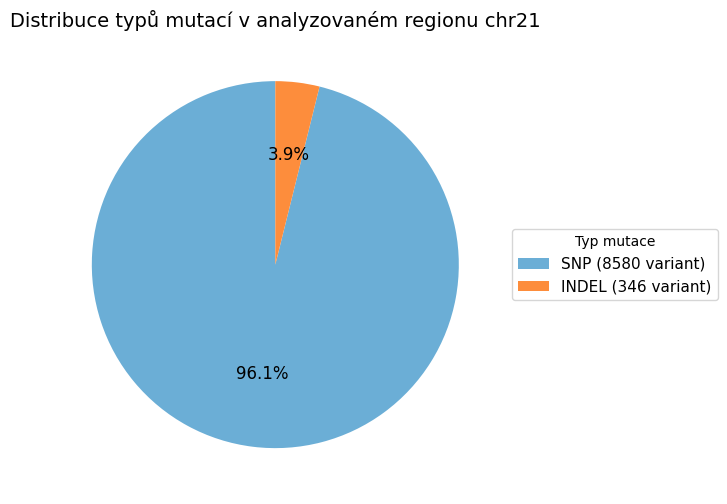

In [703]:
counts = df_variants['VAR_TYPE'].value_counts()


colors = ['#6baed6', '#fd8d3c'] 


plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    counts,
    labels=None,          # potlačí přímé popisky, legendu dáme zvlášť
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title('Distribuce typů mutací v analyzovaném regionu chr21', fontsize=14)

plt.legend(
    wedges,
    [f"{label} ({count} variant)" for label, count in zip(counts.index, counts)],
    title="Typ mutace",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.tight_layout() # automaticky upraví rozmístění prvků v grafu (např. os, názvů, popisků, legend), aby se nepřekrývaly a vše bylo dobře čitelné.
plt.show()


In [704]:
## frekvence genotypů
genotype_counter = Counter()

for gts in df_variants['GT']:
    for gt in gts:
        if gt[2]:  # valid=True
            key = f"{gt[0]}/{gt[1]}"
            genotype_counter[key] += 1
        else:
            genotype_counter['missing'] += 1

genotype_counter


Counter({'0/0': 21271851,
         '1/1': 404399,
         '1/0': 330377,
         '0/1': 330088,
         '2/0': 4976,
         '0/2': 4946,
         '2/2': 2530,
         '2/3': 288,
         '3/2': 285,
         '2/1': 244,
         '1/2': 241,
         '3/0': 172,
         '0/3': 154,
         '3/3': 100,
         '1/3': 32,
         '3/1': 21})


| Genotyp                                              | Význam                                                   | Počet                           | Poznámka                             |
| ---------------------------------------------------- | -------------------------------------------------------- | ------------------------------- | ------------------------------------ |
| **0/0**                                              | homozygot pro referenční alelu                           | 21 271 851                      | drtivá většina vzorků bez mutace     |
| **0/1**, **1/0**                                     | heterozygotní (1 mutovaná + 1 referenční alela)          | 330 088 + 330 377 ≈ **660 465** | běžné varianty                       |
| **1/1**                                              | homozygot pro alternativní alelu (mutace v obou kopiích) | 404 399                         | poměrně málo, což odpovídá očekávání |
| **2/0**, **0/2**, **2/2**, **2/3**, **3/2**, **3/3** | varianty s více než jednou alternativní alelou           | dohromady < 1 %                 | jde o vzácné multi-alelické pozice   |
| **ostatní (1/3, 3/1)**                               | velmi vzácné genotypy                                    | < 100 případů                   | zanedbatelné                         |


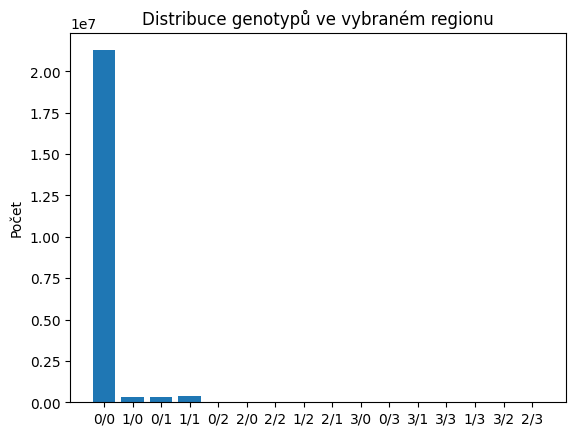

In [705]:
plt.bar(genotype_counter.keys(), genotype_counter.values())
plt.title("Distribuce genotypů ve vybraném regionu")
plt.ylabel("Počet")
plt.show()

In [706]:
maf_list = []

for gts in df_variants['GT']:
    alt_alleles = sum((gt[0] != 0) + (gt[1] != 0) for gt in gts if gt[2])  # počítá každou ne-referenční alelu jako 1
    total_alleles = 2 * sum(1 for gt in gts if gt[2])
    af = alt_alleles / total_alleles if total_alleles > 0 else 0  # frekvence alternativní alely
    maf = min(af, 1 - af)  # MAF = menší z obou frekvencí
    maf_list.append(maf)

df_variants['MAF'] = maf_list
print(df_variants[['POS','MAF']].head(10))

        POS       MAF
0  36200030  0.000799
1  36200031  0.000000
2  36200039  0.000200
3  36200095  0.000200
4  36200130  0.000399
5  36200148  0.000200
6  36200152  0.000998
7  36200156  0.000200
8  36200190  0.001997
9  36200272  0.003994


Každý řádek odpovídá variantě, a MAF ukazuje, jak častá ta mutace je ve vzorcích.
Nízké MAF (např. <0.05) označují vzácné mutace,
zatímco hodnoty kolem 0.5 ukazují velmi běžné polymorfismy.

| Hodnota MAF        | Biologický význam                       | Interpretace                                                                                                      |
| ------------------ | --------------------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **0.0002 – 0.006** | velmi nízká frekvence (vzácná varianta) | tato mutace se vyskytuje jen u několika málo jedinců                                                              |
| **0.01 – 0.05**    | nízkofrekvenční varianta                | mírně častější, ale stále relativně vzácná                                                                        |
| **0.05 – 0.5**     | běžná varianta                          | mutace přítomná u významné části populace                                                                         |
| **1.0**            | fixovaná alternativní alela             | ve všech vzorcích má místo referenční báze mutovanou bázi – může to být technický artefakt, nebo záměna reference |



0≤MAF≤0.5
protože jde o frekvenci alely v populaci, která nikdy nemůže být vyšší než 100 % a vždy se vztahuje k méně časté z obou alel (tedy maximálně 50 %).

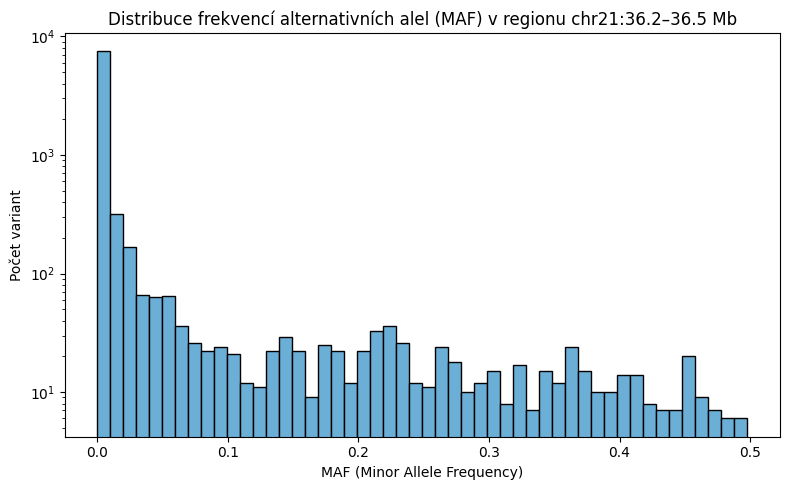

In [707]:
plt.figure(figsize=(8, 5))
plt.hist(df_variants['MAF'], bins=50, color='#6baed6', edgecolor='black')
plt.title('Distribuce frekvencí alternativních alel (MAF) v regionu chr21:36.2–36.5 Mb')
plt.xlabel('MAF (Minor Allele Frequency)')
plt.ylabel('Počet variant')
plt.yscale('log')  # logaritmická osa kvůli velkým rozdílům
plt.tight_layout()
plt.show()


In [708]:
# Definice kategorií MAF
bins = [0, 0.001, 0.01, 0.05, 0.5]  # ultra-vzácné, vzácné, nízkofrekvenční, běžné
labels = ["Ultra-rare (<0.001)",'Rare (0.001-0.01)', 'Low-frequency (0.01–0.05)', 'Common  (>0.05)']

# Zařazení variant do kategorií
df_variants['MAF_category'] = pd.cut(df_variants['MAF'], bins=bins, labels=labels, include_lowest=True)

# Spočítání počtu variant a procent
maf_summary = df_variants['MAF_category'].value_counts().sort_index()
maf_percent = (maf_summary / len(df_variants) * 100).round(2)

# Sestavení tabulky
maf_table = pd.DataFrame({
    'Počet variant': maf_summary,
    'Procento (%)': maf_percent
})

maf_table

,Počet variant,Procento (%)
MAF_category,,
Ultra-rare (<0.001),5847,65.51
Rare (0.001-0.01),1678,18.80
Low-frequency (0.01–0.05),611,6.85
Common (>0.05),790,8.85


Drtivá většina mutací je vzácná (84,3 %).
→ Většina genetických změn se v populaci vyskytuje jen u pár lidí.
Nízkofrekvenční a běžné varianty dohromady tvoří ~15 %.
→ Jen malá část mutací je častější a může být sdílena mezi více lidmi.
Celkový počet variant = 7525 + 611 + 790 = 8926, což odpovídá počtu všech variant v analyzovaném regionu.

In [709]:
## kontrola
print(df_variants['MAF'].describe())
print("Počet >1:", (df_variants['MAF'] > 1).sum())
print("Počet <0:", (df_variants['MAF'] < 0).sum())

count    8926.000000
mean        0.022389
std         0.073713
min         0.000000
25%         0.000200
50%         0.000399
75%         0.002796
max         0.498003
Name: MAF, dtype: float64
Počet >1: 0
Počet <0: 0


In [710]:
df_cadd = pd.read_csv("CADD_chr21_renamed.tsv", sep="\t") 
df_cadd.head()

,CHROM,POS,REF,ALT,RawScore,PHRED
0,21,36200000,C,A,0.145422,3.662
1,21,36200000,C,G,0.130968,3.464
2,21,36200000,C,T,0.200044,4.409
3,21,36200001,C,A,0.034345,2.264
4,21,36200001,C,G,0.021171,2.126


In [711]:
# Převod CHROM na string
df_variants['CHROM'] = df_variants['CHROM'].astype(str)
df_cadd['CHROM'] = df_cadd['CHROM'].astype(str)

In [712]:
# Vybereme jen potřebné sloupce z CADD
df_cadd_subset = df_cadd[['CHROM', 'POS', 'REF', 'ALT', 'PHRED']]

# Merge – zachováme všechny ostatní sloupce z VCF
df_merged = pd.merge(df_variants, df_cadd_subset, on=["CHROM", "POS", "REF", "ALT"], how="left")

df_merged.head()



,CHROM,POS,ID,REF,ALT,QUAL,FILTER,AF,AC,AN,...,SAS_AF,AA,EX_TARGET,MULTI_ALLELIC,GT,VAR_TYPE,DOMINANT_POP,MAF,MAF_category,PHRED
0,21,36200030,.,A,G,100.0,PASS,0.000799,4,5008,...,0.0041,A|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,SAS,0.000799,Ultra-rare (<0.001),4.846
1,21,36200031,.,C,G,100.0,PASS,1.000000,5008,5008,...,1.0000,G|||,False,False,"[[1, 1, True], [1, 1, True], [1, 1, True], [1,...",SNP,EAS,0.000000,Ultra-rare (<0.001),1.694
2,21,36200039,.,G,A,100.0,PASS,0.000200,1,5008,...,0.0000,G|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,AFR,0.000200,Ultra-rare (<0.001),1.140
3,21,36200095,.,C,T,100.0,PASS,0.000200,1,5008,...,0.0010,C|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,SAS,0.000200,Ultra-rare (<0.001),5.803
4,21,36200130,.,C,A,100.0,PASS,0.000399,2,5008,...,0.0000,C|||,False,False,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,EAS,0.000399,Ultra-rare (<0.001),1.171


In [713]:
# --- OPRAVA ID VARIANTY ---
print("Opravuji 'variant_id'...")

# Vytvoření unikátního identifikátoru varianty (variant_id)
# Formát: CHROM_POS_REF_ALT (např. 21_36200030_A_G)
# U multi-alelických variant nahrazujeme čárky v ALT pomlčkou,
# aby čárka nerozbila formát (např. ALT "TA,C" → "TA-C")
df_merged['ALT_safe'] = df_merged['ALT'].str.replace(',', '-')

# 2. Vytvoříme variant_id z této "bezpečné" verze
# Toto přepíše starý 'variant_id', pokud už existoval
df_merged['variant_id'] = (
    df_merged['CHROM'].astype(str) + '_' +
    df_merged['POS'].astype(str) + '_' +
    df_merged['REF'] + '_' +
    df_merged['ALT_safe'] # <-- Používáme opravený ALT_safe
)

# 3. Ověření:
print("Příklad problematické varianty po opravě:")
# Najdeme původní řádky, které měly v ALT čárku
problem_variants = df_merged[df_merged['ALT'].str.contains(',')]
# Vypíšeme, jak vypadá starý ALT, opravený ALT_safe a nový variant_id
problem_variants[['ALT', 'ALT_safe', 'variant_id']].head()

Opravuji 'variant_id'...
Příklad problematické varianty po opravě:


,ALT,ALT_safe,variant_id
143,"TA,C",TA-C,21_36205486_CA_TA-C
149,"A,G",A-G,21_36205590_T_A-G
421,"G,T",G-T,21_36213920_C_G-T
646,"G,TAA",G-TAA,21_36221714_T_G-TAA
650,"TTATA,T",TTATA-T,21_36221778_TTA_TTATA-T


In [ ]:
# Vytvoří nový, třístavový kategorický sloupec 'Impact'
conditions = [
    df_merged['PHRED'] >= 20,
    (df_merged['PHRED'] >= 10) & (df_merged['PHRED'] < 20),
    df_merged['PHRED'] < 10
]

choices = [
    'Deleterious',  # Kategorie pro PHRED >= 20
    'Possibly_damaging',  # Kategorie pro PHRED 10–19
    'Benign'        # Kategorie pro PHRED < 10
]

# default='Unknown' se automaticky použije tam, kde PHRED je NaN
df_merged['Impact'] = np.select(conditions, choices, default='Unknown')

# Nechá i původní sloupec 'Deleterious' jen pro True
# Tento sloupec bude mít NaN tam, kde PHRED chybí
df_merged['Deleterious'] = df_merged['PHRED'] >= 20

# Kontrola
print("Počet variant v každé kategorii dopadu:")
print(df_merged['Impact'].value_counts())

print("\nKontrola chybějících hodnot ve sloupci 'Deleterious':")
print(df_merged['Deleterious'].isnull().sum())

df_merged.head()

Počet variant v každé kategorii dopadu:
Impact
Benign               7746
Possibly_damaging     753
Unknown               376
Deleterious            51
Name: count, dtype: int64

Kontrola chybějících hodnot ve sloupci 'Deleterious':
0


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,AF,AC,AN,...,GT,VAR_TYPE,DOMINANT_POP,MAF,MAF_category,PHRED,ALT_safe,variant_id,Impact,Deleterious
0,21,36200030,.,A,G,100.0,PASS,0.000799,4,5008,...,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,SAS,0.000799,Ultra-rare (<0.001),4.846,G,21_36200030_A_G,Benign,False
1,21,36200031,.,C,G,100.0,PASS,1.000000,5008,5008,...,"[[1, 1, True], [1, 1, True], [1, 1, True], [1,...",SNP,EAS,0.000000,Ultra-rare (<0.001),1.694,G,21_36200031_C_G,Benign,False
2,21,36200039,.,G,A,100.0,PASS,0.000200,1,5008,...,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,AFR,0.000200,Ultra-rare (<0.001),1.140,A,21_36200039_G_A,Benign,False
3,21,36200095,.,C,T,100.0,PASS,0.000200,1,5008,...,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,SAS,0.000200,Ultra-rare (<0.001),5.803,T,21_36200095_C_T,Benign,False
4,21,36200130,.,C,A,100.0,PASS,0.000399,2,5008,...,"[[0, 0, True], [0, 0, True], [0, 0, True], [0,...",SNP,EAS,0.000399,Ultra-rare (<0.001),1.171,A,21_36200130_C_A,Benign,False


In [715]:
print(df_merged['PHRED'].describe())
print()
print(df_merged['PHRED'].value_counts(bins=10))

count    8550.000000
mean        3.689785
std         4.303109
min         0.001000
25%         0.694000
50%         2.089500
75%         5.072500
max        34.000000
Name: PHRED, dtype: float64

(-0.034, 3.401]     5478
(3.401, 6.801]      1587
(6.801, 10.201]      708
(10.201, 13.601]     353
(13.601, 17.001]     261
(17.001, 20.4]       117
(20.4, 23.8]          39
(23.8, 27.2]           5
(30.6, 34.0]           2
(27.2, 30.6]           0
Name: count, dtype: int64


In [716]:
meta=pd.read_csv("igsr_samples.tsv", sep="\t", encoding='latin-1')

meta.head(10)

,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG00152,male,SAME124593,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1KG_ONT_VIENNA,1000 Gen..."
1,HG00157,male,SAME124590,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00171,female,SAME124961,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,HG00176,female,SAME124956,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
4,HG00183,male,SAME123642,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
5,HG00188,male,SAME123641,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
6,HG00190,male,SAME123856,FIN,"Finnish,Finnish",EUR,"European Ancestry,West Eurasia (SGDP)","FIN,FinnishSGDP","1000 Genomes on GRCh38,Simons Genome Diversity..."
7,HG00234,male,SAME124123,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
8,HG00239,female,SAME124130,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
9,HG00246,male,SAME123219,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


In [717]:
meta.columns

# Počet unikátních hodnot v každém sloupci
unique_counts = meta.nunique()
print(unique_counts)

Sample name              4989
Sex                         2
Biosample ID             3744
Population code            31
Population name           173
Superpopulation code        6
Superpopulation name       30
Population elastic ID     220
Data collections          124
dtype: int64


In [718]:
# Získáme seznam vzorků PŘESNĚ v tom pořadí, 
# jak jsou uloženy v VCF souboru (a tedy i ve sloupci 'GT')
sample_ids = vcf.samples

# Převedeme ho na DataFrame
df_samples = pd.DataFrame({'Sample name': sample_ids})

# Vybereme si z metadat jen sloupce, které nás zajímají
# (můžeš si sem přidat jakékoli další sloupce z 'meta', které chceš)
meta_subset = meta[['Sample name', 'Sex', 'Population code', 'Superpopulation code']]

# Připojíme metadata k našim VCF vzorkům
# Děláme 'left' merge, abychom zachovali pořadí z df_samples
df_samples_meta = pd.merge(df_samples, meta_subset, on='Sample name', how='left')

# Zkontrolujeme, jestli je vše v pořádku
print(f"Počet vzorků v našem VCF: {len(df_samples_meta)}")
print("\nPočet nespárovaných vzorků (měl by být 0):")
print(df_samples_meta['Superpopulation code'].isnull().sum())

print("\nPrvních 5 vzorků s metadaty:")
df_samples_meta.head()

Počet vzorků v našem VCF: 2504

Počet nespárovaných vzorků (měl by být 0):
0

Prvních 5 vzorků s metadaty:


,Sample name,Sex,Population code,Superpopulation code
0,HG00096,male,GBR,EUR
1,HG00097,female,GBR,EUR
2,HG00099,female,GBR,EUR
3,HG00100,female,GBR,EUR
4,HG00101,male,GBR,EUR


In [719]:
# Oprava jednoho vzorku s nestandartní superpopulací "EUR,AFR" — vezmeme první hodnotu
df_samples_meta['Superpopulation code'] = df_samples_meta['Superpopulation code'].str.split(',').str[0]
print(df_samples_meta['Superpopulation code'].value_counts())

Superpopulation code
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64


## Matice pro úlohy 1 a 3
**1. Soubor asociačních pravidel mezi mutacemi genů** 

**2. Asociační pravidla mezi mutacemi a populacemi**

In [ ]:
# Z `df_merged` vybereme jen varianty, které jsou "zajímavé" pro asociační pravidla
#  s MAF mezi 1% a 50%
MIN_MAF = 0.01
MAX_MAF = 0.5 

df_variants_assoc = df_merged[
    (df_merged['MAF'] >= MIN_MAF) &
    (df_merged['MAF'] <= MAX_MAF)
].copy()

# Vytvoříme pro ně unikátní ID
df_variants_assoc['variant_id'] = (
    df_variants_assoc['CHROM'].astype(str) + '_' +
    df_variants_assoc['POS'].astype(str) + '_' +
    df_variants_assoc['REF'] + '_' +
    df_variants_assoc['ALT_safe']
)

print(f"Počet všech variant: {len(df_merged)}")
print(f"Počet variant pro analýzu (MAF {MIN_MAF}-{MAX_MAF}): {len(df_variants_assoc)}")

Počet všech variant: 8926
Počet variant pro analýzu (MAF 0.01-0.5): 1401


In [721]:
# Připravíme si "transakce" - seznam seznamů
# Každý vnitřní seznam bude "košík" jednoho člověka
transaction_items_list = []

# Získáme seznamy ID variant a genotypů pro rychlejší přístup
variant_ids_to_add = df_variants_assoc['variant_id'].tolist()
genotypes_list = df_variants_assoc['GT'].tolist()

In [722]:
# Iterujeme přes VŠECHNY VZORKY (lidi)
for i in range(len(df_samples_meta)):

    sample_data = df_samples_meta.iloc[i]
    sample_basket = [] # Košík pro tohoto jednoho člověka
    
    # 1. Přidáme METADATA jako položky
    # Použijeme prefixy, aby bylo jasné, o co jde (např. 'Pop_GBR')
    sample_basket.append(f"Sex_{sample_data['Sex']}")
    sample_basket.append(f"Pop_{sample_data['Population code']}")
    sample_basket.append(f"SuperPop_{sample_data['Superpopulation code']}")

    # 2. Přidáme MUTACE
    # Projdeme všechny varianty,které jsme si vyfiltrovali
    for j in range(len(variant_ids_to_add)):
        variant_id = variant_ids_to_add[j]
        genotype = genotypes_list[j][i] # Genotyp j-té varianty pro i-tého člověka
        
        # Podmínka: Genotyp je validní A NENÍ referenční (0/0)
        has_variant = (genotype[0] > 0 or genotype[1] > 0) and genotype[2]
        
        if has_variant:
            sample_basket.append(variant_id)
            
    # Přidáme hotový košík tohoto člověka do celkového seznamu
    transaction_items_list.append(sample_basket)

print("Hotovo. Příklad 'košíku' prvního člověka:")
print(transaction_items_list[0])

Hotovo. Příklad 'košíku' prvního člověka:
['Sex_male', 'Pop_GBR', 'SuperPop_EUR', '21_36202440_T_C', '21_36202775_C_T', '21_36206142_C_G', '21_36208167_G_A', '21_36209023_T_A', '21_36211188_C_G', '21_36212037_T_C', '21_36213879_T_C', '21_36213897_A_G', '21_36215354_G_A', '21_36218491_CT_C', '21_36221072_T_C', '21_36222139_T_A', '21_36223627_G_A', '21_36224963_C_G', '21_36224983_T_C-G', '21_36226645_A_T', '21_36226796_C_T', '21_36227051_ACGGGCTG_A', '21_36227414_C_T', '21_36227547_T_A', '21_36227745_C_T', '21_36227924_C_T', '21_36229941_C_T', '21_36229995_C_A', '21_36231159_A_C', '21_36231175_C_T', '21_36231613_G_A', '21_36232156_C_A', '21_36232482_T_C', '21_36232535_T_C', '21_36232671_T_C', '21_36233176_T_C', '21_36233756_T_G', '21_36234200_C_A', '21_36234325_T_TAA', '21_36234423_G_C-GAC', '21_36234697_T_C', '21_36235568_C_A', '21_36235739_A_G', '21_36264005_A_T', '21_36271158_C_T', '21_36272062_C_G', '21_36274936_T_C', '21_36279933_C_T', '21_36280897_T_C', '21_36282225_C_T', '21_36289

In [723]:
te = TransactionEncoder()
te_ary = te.fit_transform(transaction_items_list)

# Řádky = lidé, Sloupce = položky (mutace + metadata)
matrix_lide = pd.DataFrame(te_ary, columns=te.columns_)
matrix_lide.index = df_samples_meta['Sample name']

print("\nFinální matrix_lide (připravena):")
matrix_lide.head()


Finální matrix_lide (připravena):


,21_36200285_G_A,21_36200305_A_G,21_36201079_C_CT,21_36201101_T_C,21_36201192_C_T,21_36202440_T_C,21_36202473_A_G,21_36202482_T_C,21_36202775_C_T,21_36203846_G_A,...,Pop_STU,Pop_TSI,Pop_YRI,Sex_female,Sex_male,SuperPop_AFR,SuperPop_AMR,SuperPop_EAS,SuperPop_EUR,SuperPop_SAS
Sample name,,,,,,,,,,,,,,,,,,,,,
HG00096,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
HG00097,False,False,False,False,False,True,False,False,True,True,...,False,False,False,True,False,False,False,False,True,False
HG00099,False,False,False,False,False,False,False,False,True,True,...,False,False,False,True,False,False,False,False,True,False
HG00100,False,False,False,False,False,True,False,False,True,True,...,False,False,False,True,False,False,False,False,True,False
HG00101,False,False,False,False,False,True,False,False,True,True,...,False,False,False,False,True,False,False,False,True,False


In [724]:
# Kontrola — kolik lidí má nestandartní superpopulaci?
print(df_samples_meta['Superpopulation code'].value_counts())

Superpopulation code
AFR    661
EAS    504
EUR    503
SAS    489
AMR    347
Name: count, dtype: int64


In [725]:
print([col for col in matrix_lide.columns if 'SuperPop' in col])

['SuperPop_AFR', 'SuperPop_AMR', 'SuperPop_EAS', 'SuperPop_EUR', 'SuperPop_SAS']


## Matice pro úlohu 2
**2. Asociační pravidla mezi vlastnostmi genetických varian** 

In [ ]:
# V našem hlavním DataFrame `df_merged` vytvoříme 'variant_id'
df_merged['variant_id'] = (
  df_merged['CHROM'].astype(str) + '_' +
   df_merged['POS'].astype(str) + '_' +
   df_merged['REF'] + '_' +
   df_merged['ALT_safe']
)

# Vybereme sloupce, které chceme převést, ALE NECHÁME SI 'variant_id'
features_to_encode = ['MAF_category', 'Impact', 'DOMINANT_POP']

# Zkopírujeme si relevantní část dat
features_df = df_merged[['variant_id'] + features_to_encode].copy()

features_df_clean = features_df[features_df['Impact'] != 'Unknown'].copy()

features_df_clean = features_df_clean.set_index('variant_id')

# Aplikujeme get_dummies na čistý DataFrame
# Index (variant_id) zůstane zachován
matrix_varianty = pd.get_dummies(features_df_clean, dtype=int)

print("Finální matrix_varianty:")
matrix_varianty.head()


Finální matrix_varianty:


,MAF_category_Ultra-rare (<0.001),MAF_category_Rare (0.001-0.01),MAF_category_Low-frequency (0.01–0.05),MAF_category_Common (>0.05),Impact_Benign,Impact_Deleterious,Impact_Possibly_damaging,DOMINANT_POP_AFR,DOMINANT_POP_AMR,DOMINANT_POP_EAS,DOMINANT_POP_EUR,DOMINANT_POP_NONE,DOMINANT_POP_SAS
variant_id,,,,,,,,,,,,,
21_36200030_A_G,1,0,0,0,1,0,0,0,0,0,0,0,1
21_36200031_C_G,1,0,0,0,1,0,0,0,0,1,0,0,0
21_36200039_G_A,1,0,0,0,1,0,0,1,0,0,0,0,0
21_36200095_C_T,1,0,0,0,1,0,0,0,0,0,0,0,1
21_36200130_C_A,1,0,0,0,1,0,0,0,0,1,0,0,0


In [727]:
print(f"Rozměr: {matrix_varianty.shape}")
print(f"Sloupce: {list(matrix_varianty.columns)}")

Rozměr: (8550, 13)
Sloupce: ['MAF_category_Ultra-rare (<0.001)', 'MAF_category_Rare (0.001-0.01)', 'MAF_category_Low-frequency (0.01–0.05)', 'MAF_category_Common  (>0.05)', 'Impact_Benign', 'Impact_Deleterious', 'Impact_Possibly_damaging', 'DOMINANT_POP_AFR', 'DOMINANT_POP_AMR', 'DOMINANT_POP_EAS', 'DOMINANT_POP_EUR', 'DOMINANT_POP_NONE', 'DOMINANT_POP_SAS']


In [728]:
print(f"Rozměr po odstranění konstantního sloupce: {matrix_varianty.shape}")

Rozměr po odstranění konstantního sloupce: (8550, 13)


In [729]:
print("Finální matrix_varianty:")
matrix_varianty.head()

Finální matrix_varianty:


,MAF_category_Ultra-rare (<0.001),MAF_category_Rare (0.001-0.01),MAF_category_Low-frequency (0.01–0.05),MAF_category_Common (>0.05),Impact_Benign,Impact_Deleterious,Impact_Possibly_damaging,DOMINANT_POP_AFR,DOMINANT_POP_AMR,DOMINANT_POP_EAS,DOMINANT_POP_EUR,DOMINANT_POP_NONE,DOMINANT_POP_SAS
variant_id,,,,,,,,,,,,,
21_36200030_A_G,1,0,0,0,1,0,0,0,0,0,0,0,1
21_36200031_C_G,1,0,0,0,1,0,0,0,0,1,0,0,0
21_36200039_G_A,1,0,0,0,1,0,0,1,0,0,0,0,0
21_36200095_C_T,1,0,0,0,1,0,0,0,0,0,0,0,1
21_36200130_C_A,1,0,0,0,1,0,0,0,0,1,0,0,0


In [730]:
# Převedeme na bool
matrix_varianty_bool = matrix_varianty.astype(bool)

print(f"Rozměr: {matrix_varianty_bool.shape}")
print(f"Sloupce: {list(matrix_varianty_bool.columns)}")
matrix_varianty_bool.head()

Rozměr: (8550, 13)
Sloupce: ['MAF_category_Ultra-rare (<0.001)', 'MAF_category_Rare (0.001-0.01)', 'MAF_category_Low-frequency (0.01–0.05)', 'MAF_category_Common  (>0.05)', 'Impact_Benign', 'Impact_Deleterious', 'Impact_Possibly_damaging', 'DOMINANT_POP_AFR', 'DOMINANT_POP_AMR', 'DOMINANT_POP_EAS', 'DOMINANT_POP_EUR', 'DOMINANT_POP_NONE', 'DOMINANT_POP_SAS']


,MAF_category_Ultra-rare (<0.001),MAF_category_Rare (0.001-0.01),MAF_category_Low-frequency (0.01–0.05),MAF_category_Common (>0.05),Impact_Benign,Impact_Deleterious,Impact_Possibly_damaging,DOMINANT_POP_AFR,DOMINANT_POP_AMR,DOMINANT_POP_EAS,DOMINANT_POP_EUR,DOMINANT_POP_NONE,DOMINANT_POP_SAS
variant_id,,,,,,,,,,,,,
21_36200030_A_G,True,False,False,False,True,False,False,False,False,False,False,False,True
21_36200031_C_G,True,False,False,False,True,False,False,False,False,True,False,False,False
21_36200039_G_A,True,False,False,False,True,False,False,True,False,False,False,False,False
21_36200095_C_T,True,False,False,False,True,False,False,False,False,False,False,False,True
21_36200130_C_A,True,False,False,False,True,False,False,False,False,True,False,False,False


### znalostní graf

In [731]:
g = Graph()

# Definice jmenného prostoru
ex = Namespace("http://mojebakalarka.cz/ontologie#")
g.bind("ex", ex)

# === 1. METADATA LIDÍ ===
print("Přidávám metadata lidí...")
for _, row in df_samples_meta.iterrows():
    osoba = ex[row['Sample name']]
    g.add((osoba, RDF.type, ex.Osoba))
    g.add((osoba, ex.maPohlavi, Literal(row['Sex'], datatype=XSD.string)))
    g.add((osoba, ex.maPopulaci, Literal(row['Population code'], datatype=XSD.string)))
    g.add((osoba, ex.maSuperPopulaci, Literal(row['Superpopulation code'], datatype=XSD.string)))

# === 2. METADATA VARIANT ===
print("Přidávám metadata variant...")
# Pouze varianty se známým dopadem (vyřazujeme Unknown = chybějící CADD skóre)
df_variants_rdf = df_merged[df_merged['Impact'] != 'Unknown'].copy()

for _, row in df_variants_rdf.iterrows():
    varianta = ex[row['variant_id']]
    g.add((varianta, RDF.type, ex.Varianta))
    g.add((varianta, ex.maDopad, Literal(row['Impact'], datatype=XSD.string)))
    g.add((varianta, ex.maMAF, Literal(float(row['MAF']), datatype=XSD.float)))
    g.add((varianta, ex.maMAFKategorii, Literal(str(row['MAF_category']), datatype=XSD.string)))
    g.add((varianta, ex.maDominantniPopulaci, Literal(row['DOMINANT_POP'], datatype=XSD.string)))
    g.add((varianta, ex.maPozici, Literal(int(row['POS']), datatype=XSD.integer)))

# === 3. VZTAHY ČLOVĚK → VARIANTA ===
print("Přidávám vztahy člověk-varianta...")
# Používáme filtrované varianty (MAF 0.01–0.5), konzistentní s matrix_lide
for i in range(len(df_samples_meta)):
    osoba = ex[df_samples_meta.iloc[i]['Sample name']]
    
    for j in range(len(variant_ids_to_add)):
        genotype = genotypes_list[j][i]
        # Člověk má variantu pokud nese alespoň jednu alternativní alelu
        if (genotype[0] > 0 or genotype[1] > 0) and genotype[2]:
            g.add((osoba, ex.maVariantu, ex[variant_ids_to_add[j]]))

print(f"\nHotovo! Graf má celkem {len(g)} trojic.")

# Uložení grafu
g.serialize(destination="rdf_graph_final.ttl", format="turtle")
print("Graf uložen do souboru 'rdf_graph.ttl'.")

Přidávám metadata lidí...
Přidávám metadata variant...
Přidávám vztahy člověk-varianta...

Hotovo! Graf má celkem 1005045 trojic.
Graf uložen do souboru 'rdf_graph.ttl'.


In [732]:
g = Graph()
g.parse("rdf_graph_final.ttl", format="turtle")

PREFIX = "http://mojebakalarka.cz/ontologie#"
RDF_TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"

# Přeskočíme numerické predikáty (maPozici, maMAF) a rdf:type
SKIP = {PREFIX + "maPozici", PREFIX + "maMAF", RDF_TYPE}

count = 0
with open("amie_triples.tsv", "w") as f:
    for s, p, o in g:
        if str(p) in SKIP:
            continue
        s_short = str(s).replace(PREFIX, "")
        p_short = str(p).replace(PREFIX, "")
        o_short = str(o).replace(PREFIX, "")
        f.write(f"{s_short}\t{p_short}\t{o_short}\n")
        count += 1

print(f"Exportováno {count} trojic")




Exportováno 976891 trojic


In [733]:
from rdflib import Graph, Namespace
from collections import Counter

g = Graph()
g.parse("rdf_graph_final.ttl", format="turtle")

ex = Namespace("http://mojebakalarka.cz/ontologie#")

dopady = [str(o) for s, p, o in g.triples((None, ex.maDopad, None))]
print(Counter(dopady))

Counter({'Benign': 7746, 'Possibly_damaging': 753, 'Deleterious': 51})


In [ ]:
import gzip
import os

# Použijeme cestu, kterou už máš v notebooku definovanou
# vcf_file = "chromozom_21/ALL.chr21.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"

# Velikost komprimovaného souboru na disku
compressed_size = os.path.getsize(vcf_file) / (1024**2)  # Přepočet na MB

# Zjištění reálné velikosti (virtuální dekomprese)

uncompressed_size = 0
with gzip.open(vcf_file, 'rb') as f:
    for chunk in iter(lambda: f.read(10 * 1024 * 1024), b''): # Čteme po 10 MB
        uncompressed_size += len(chunk)

uncompressed_size_mb = uncompressed_size / (1024**2)
uncompressed_size_gb = uncompressed_size / (1024**3)

print(f"Velikost na disku (komprimovaně): {compressed_size:.2f} MB")
print(f"Reálná velikost (po rozbalení): {uncompressed_size_mb:.2f} MB ({uncompressed_size_gb:.2f} GB)")
print(f"Kompresní poměr: {uncompressed_size_mb / compressed_size:.2f}x")

Velikost na disku (komprimovaně): 200.06 MB
Reálná velikost (po rozbalení): 10712.08 MB (10.46 GB)
Kompresní poměr: 53.55x


In [735]:
import os
os.makedirs('data', exist_ok=True)

In [ ]:
# === Export dat pro další notebooky ===

# Matice pro FP-Growth
matrix_lide.to_pickle('data/matrix_lide.pkl')
matrix_varianty_bool.to_pickle('data/matrix_varianty_bool.pkl')
features_df_clean.to_pickle('data/features_df_clean.pkl')
df_merged.to_pickle('data/df_merged.pkl')

# RDF trojice pro AMIE jsou již uloženy v amie_triples.tsv

print('Data uložena do složky data/')

Data uložena do složky data/
